# Analysis of Pieces in CSV but not in Excel

This notebook performs analysis on:
1. `found_pieces_not_in_excel.xlsx`: Analysis of validation status (`validated`), sources, eras, and difficulty distributions for the newly found pieces.
2. `guitarburst_full.json`: Analysis of overall difficulty distributions in the complete Guitarburst dataset.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for premium aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']

# Find and load the Excel file robustly
excel_path = 'found_pieces_not_in_excel.xlsx'
if not os.path.exists(excel_path):
    excel_path = 'features/found_pieces_not_in_excel.xlsx'

print(f"Loading Excel data from: {excel_path}")
df_excel = pd.read_excel(excel_path)
print(f"Loaded {len(df_excel)} rows and {len(df_excel.columns)} columns successfully.")

Loading Excel data from: found_pieces_not_in_excel.xlsx
Loaded 778 rows and 15 columns successfully.


## 1. Frequency Distribution of the First Column (`validated`), `Era`, and `source`

Since all these new pieces are currently marked as `?` under `validated`, we also analyze their distribution by `Era` and `source` for more meaningful insights.

First column name: 'validated'

--- Frequency Table of Validation Categories ---


,Count,Percentage (%)
validated,,
?,778,100.0


/tmp/ipykernel_399462/2195800423.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


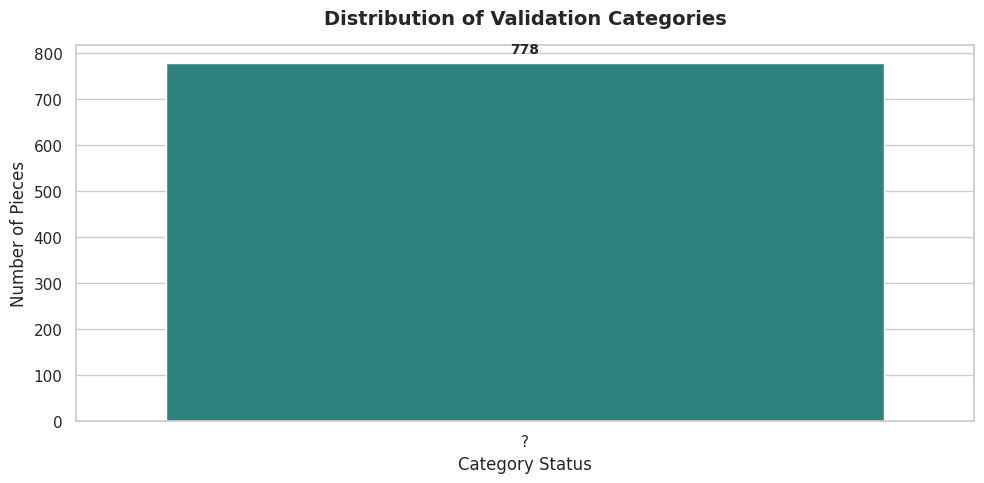


--- Frequency Table of Era ---


,Count,Percentage (%)
Era,,
Classical,237,30.46
Romantic,176,22.62
Baroque,167,21.47
Modern,136,17.48
Renaissance,62,7.97


/tmp/ipykernel_399462/2195800423.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


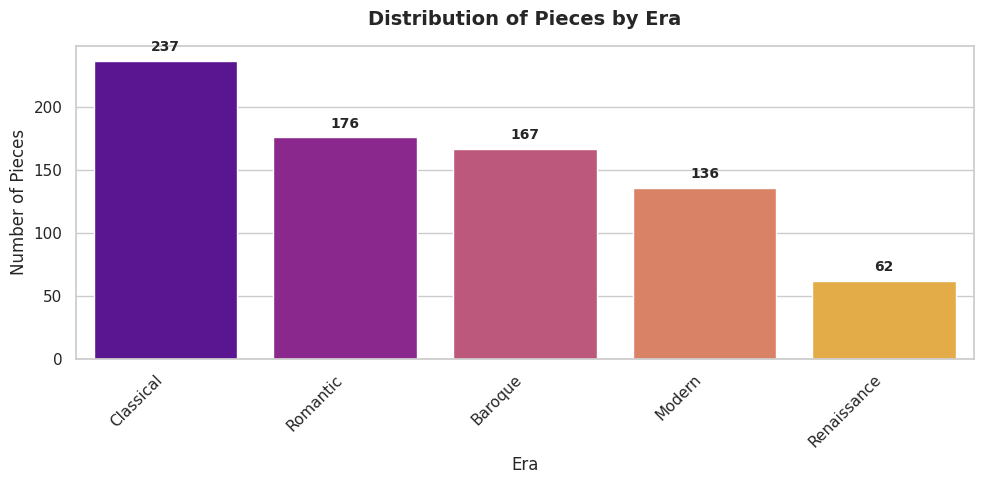


--- Frequency Table of source ---


,Count,Percentage (%)
source,,
pdf,677,87.02
dada_gp,90,11.57
gaps,11,1.41


/tmp/ipykernel_399462/2195800423.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


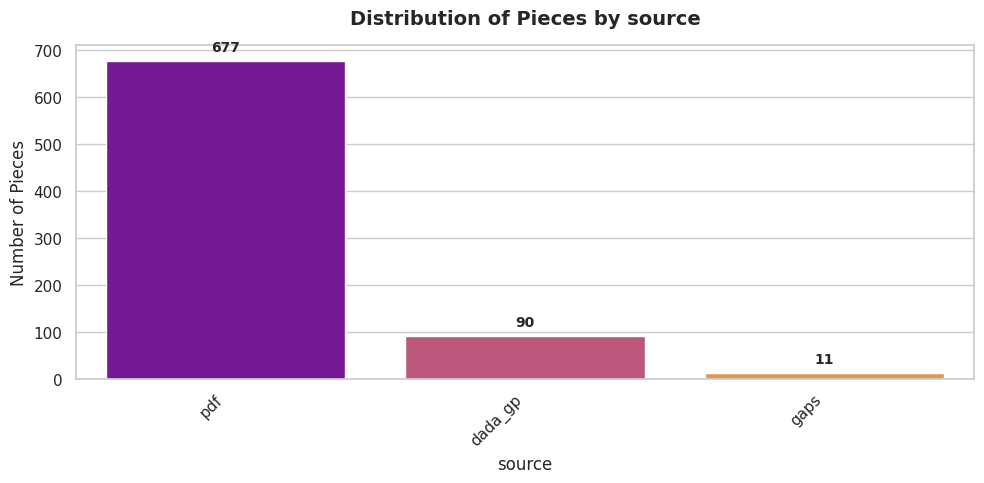

In [2]:
# Identify the first column name
first_col = df_excel.columns[0]
print(f"First column name: '{first_col}'\n")

# Compute value counts (including NaN values to see missing entries)
validation_counts = df_excel[first_col].value_counts(dropna=False)
validation_percentage = df_excel[first_col].value_counts(dropna=False, normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': validation_counts,
    'Percentage (%)': validation_percentage.round(2)
})
print("--- Frequency Table of Validation Categories ---")
display(summary_df)

# Plot validation status counts
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df_excel, 
    x=first_col, 
    order=df_excel[first_col].value_counts().index if not df_excel[first_col].empty else None,
    palette="viridis"
)
plt.title("Distribution of Validation Categories", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Category Status", fontsize=12)
plt.ylabel("Number of Pieces", fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional analysis: Era and Source
for col in ['Era', 'source']:
    if col in df_excel.columns:
        counts = df_excel[col].value_counts(dropna=False)
        pct = df_excel[col].value_counts(dropna=False, normalize=True) * 100
        sum_col = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)})
        print(f"\n--- Frequency Table of {col} ---")
        display(sum_col)
        
        plt.figure(figsize=(10, 5))
        ax = sns.countplot(
            data=df_excel,
            x=col,
            order=df_excel[col].value_counts().index if not df_excel[col].empty else None,
            palette="plasma"
)
        plt.title(f"Distribution of Pieces by {col}", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Number of Pieces", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        
        for p in ax.patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 5),
                            textcoords='offset points',
                            fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 2. Difficulty Distribution (Column D: `Difficulty`) - Excel Overall

Let's clean the column by converting non-numeric strings to `NaN` and plot the overall histogram for the new Excel file.

Difficulty column name: 'Difficulty'

Successfully parsed difficulty levels.
Total rows in Excel dataset: 778
Number of non-numeric/missing values: 0

--- Descriptive Statistics for Difficulty Levels ---


count    778.000000
mean       7.642674
std        4.141740
min        1.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       20.000000
Name: Difficulty_Cleaned, dtype: float64

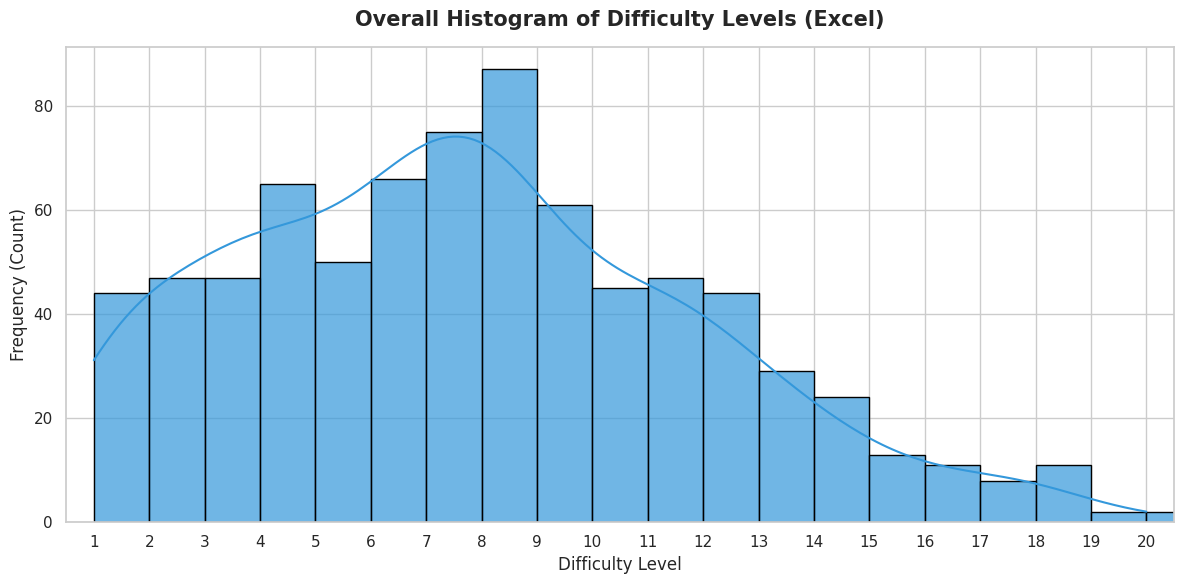

In [3]:
# Select the 4th column (Index 3, representing column D)
diff_col = df_excel.columns[3]
print(f"Difficulty column name: '{diff_col}'\n")

df_excel['Difficulty_Cleaned'] = pd.to_numeric(df_excel[diff_col], errors='coerce')

num_nans = df_excel['Difficulty_Cleaned'].isna().sum()
print(f"Successfully parsed difficulty levels.")
print(f"Total rows in Excel dataset: {len(df_excel)}")
print(f"Number of non-numeric/missing values: {num_nans}")

print("\n--- Descriptive Statistics for Difficulty Levels ---")
display(df_excel['Difficulty_Cleaned'].describe())

# Plot histogram of difficulty levels
plt.figure(figsize=(12, 6))
min_diff = int(df_excel['Difficulty_Cleaned'].min()) if not pd.isna(df_excel['Difficulty_Cleaned'].min()) else 1
max_diff = int(df_excel['Difficulty_Cleaned'].max()) if not pd.isna(df_excel['Difficulty_Cleaned'].max()) else 20
bins = range(min_diff, max_diff + 2)

sns.histplot(
    data=df_excel,
    x='Difficulty_Cleaned',
    bins=bins,
    kde=True,
    color='#3498db',
    edgecolor='black',
    alpha=0.7
)

plt.title("Overall Histogram of Difficulty Levels (Excel)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Difficulty Level", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.xticks(range(min_diff, max_diff + 1))
plt.xlim(min_diff - 0.5, max_diff + 0.5)
plt.tight_layout()
plt.show()

## 3. Difficulty Distribution by Validation Category, Era, and Source

Let's analyze the difficulty levels grouped by `validated` (for future reference), as well as by `Era` and `source` to see how difficulty varies across historical periods and data sources.

In [4]:
# Group by validation category
print("--- Difficulty Descriptive Statistics Grouped by Validation Category ---")
grouped_stats = df_excel.groupby(first_col, dropna=False)['Difficulty_Cleaned'].describe()
display(grouped_stats)

# Group by Era
if 'Era' in df_excel.columns:
    print("\n--- Difficulty Descriptive Statistics Grouped by Era ---")
    grouped_era = df_excel.groupby('Era', dropna=False)['Difficulty_Cleaned'].describe()
    display(grouped_era)

# Group by source
if 'source' in df_excel.columns:
    print("\n--- Difficulty Descriptive Statistics Grouped by Source ---")
    grouped_source = df_excel.groupby('source', dropna=False)['Difficulty_Cleaned'].describe()
    display(grouped_source)

--- Difficulty Descriptive Statistics Grouped by Validation Category ---


,count,mean,std,min,25%,50%,75%,max
validated,,,,,,,,
?,778.0,7.642674,4.14174,1.0,4.0,7.0,10.0,20.0



--- Difficulty Descriptive Statistics Grouped by Era ---


,count,mean,std,min,25%,50%,75%,max
Era,,,,,,,,
Baroque,167.0,8.742515,3.948408,1.0,6.00,8.0,11.5,19.0
Classical,237.0,4.658228,3.191167,1.0,2.00,4.0,7.0,18.0
Modern,136.0,9.919118,3.600525,1.0,8.00,9.5,12.0,20.0
Renaissance,62.0,6.241935,3.831216,1.0,3.25,5.5,8.0,18.0
Romantic,176.0,9.352273,3.412715,2.0,7.00,8.0,11.0,20.0



--- Difficulty Descriptive Statistics Grouped by Source ---


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
dada_gp,90.0,7.211111,4.498425,1.0,4.0,6.5,11.0,18.0
gaps,11.0,5.545455,3.205110,1.0,3.5,5.0,7.5,11.0
pdf,677.0,7.734121,4.098301,1.0,5.0,8.0,10.0,20.0


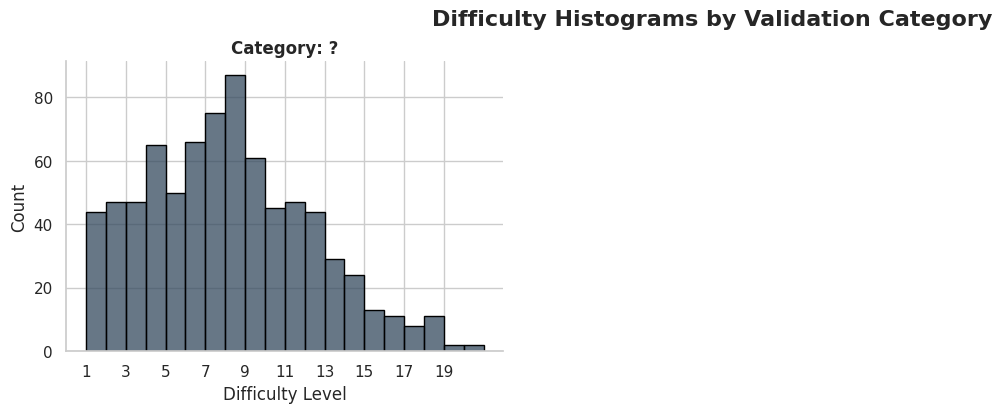

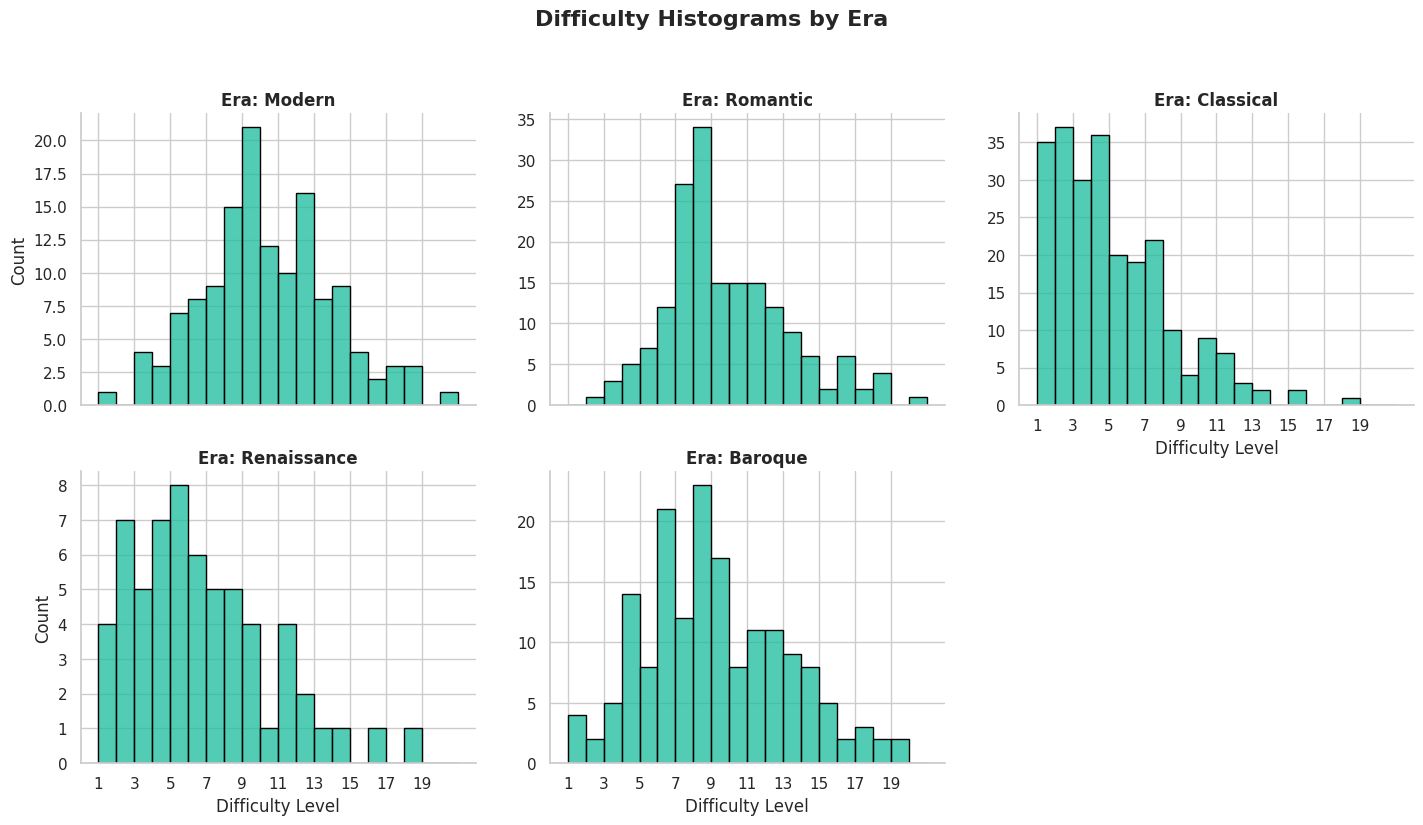

In [5]:
# Filter out rows where validation or difficulty is missing for plotting
plot_df = df_excel.dropna(subset=[first_col, 'Difficulty_Cleaned']).copy()
plot_df[first_col] = plot_df[first_col].astype(str)

min_diff = int(plot_df['Difficulty_Cleaned'].min()) if not plot_df.empty else 1
max_diff = int(plot_df['Difficulty_Cleaned'].max()) if not plot_df.empty else 20
bins = range(min_diff, max_diff + 2)

# FacetGrid by validation category
g = sns.FacetGrid(
    plot_df, 
    col=first_col, 
    col_wrap=3, 
    height=4, 
    aspect=1.2, 
    sharey=False
)
g.map(sns.histplot, 'Difficulty_Cleaned', bins=bins, color='#34495e', edgecolor='black', alpha=0.75)
g.set_titles("Category: {col_name}", size=12, weight='bold')
g.set_axis_labels("Difficulty Level", "Count")
for ax in g.axes.flat:
    ax.set_xticks(range(min_diff, max_diff + 1, 2))
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Difficulty Histograms by Validation Category", fontsize=16, fontweight='bold', y=1.03)
plt.show()

# FacetGrid by Era
if 'Era' in df_excel.columns:
    plot_df_era = df_excel.dropna(subset=['Era', 'Difficulty_Cleaned']).copy()
    plot_df_era['Era'] = plot_df_era['Era'].astype(str)
    
    g_era = sns.FacetGrid(
        plot_df_era, 
        col='Era', 
        col_wrap=3, 
        height=4, 
        aspect=1.2, 
        sharey=False
    )
    g_era.map(sns.histplot, 'Difficulty_Cleaned', bins=bins, color='#1abc9c', edgecolor='black', alpha=0.75)
    g_era.set_titles("Era: {col_name}", size=12, weight='bold')
    g_era.set_axis_labels("Difficulty Level", "Count")
    for ax in g_era.axes.flat:
        ax.set_xticks(range(min_diff, max_diff + 1, 2))
    plt.subplots_adjust(top=0.9)
    g_era.fig.suptitle("Difficulty Histograms by Era", fontsize=16, fontweight='bold', y=1.03)
    plt.show()

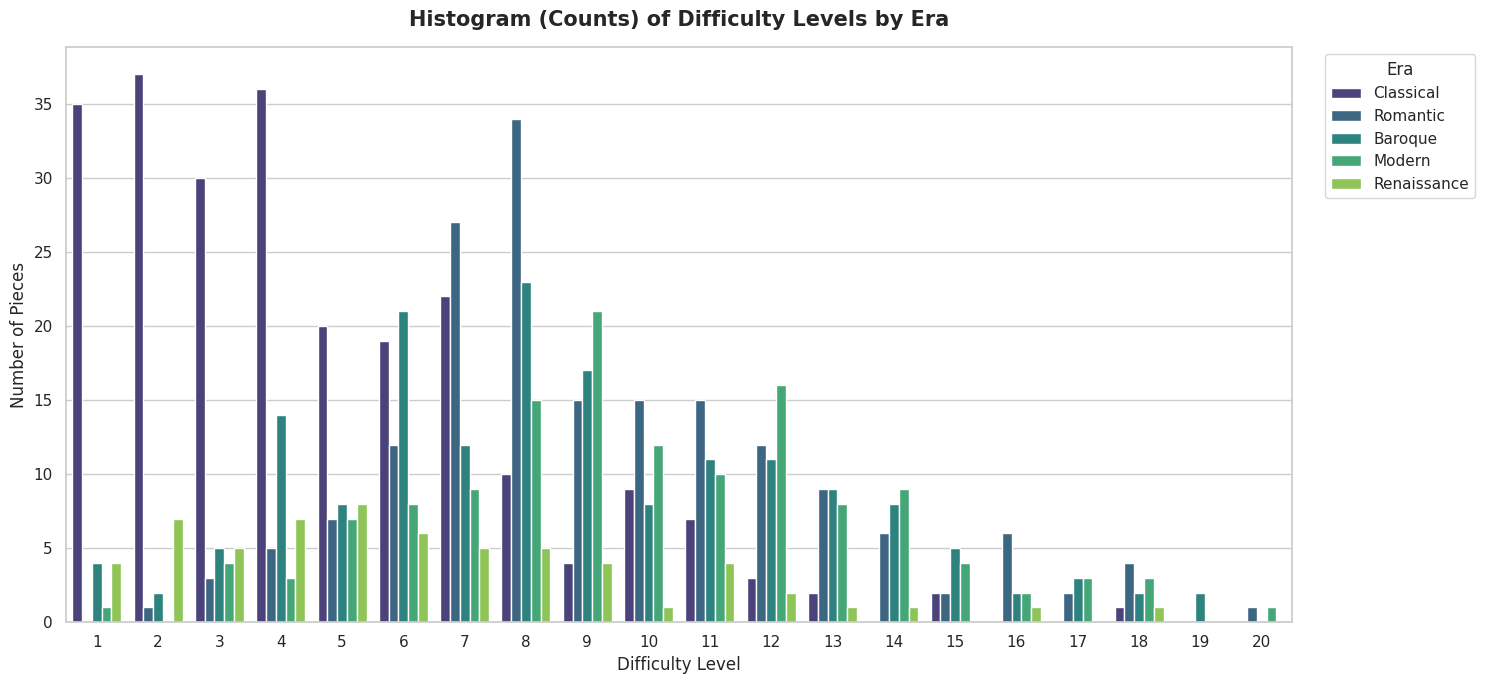

In [6]:
# Grouped Countplot showing difficulty levels color-coded by Era
if 'Era' in df_excel.columns and 'plot_df_era' in locals() and not plot_df_era.empty:
    plt.figure(figsize=(15, 7))
    era_order = plot_df_era['Era'].value_counts().index
    
    sns.countplot(
        data=plot_df_era,
        x='Difficulty_Cleaned',
        hue='Era',
        hue_order=era_order,
        palette="viridis"
    )
    
    plt.title("Histogram (Counts) of Difficulty Levels by Era", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Difficulty Level", fontsize=12)
    plt.ylabel("Number of Pieces", fontsize=12)
    plt.legend(title="Era", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 4. Difficulty Distribution in Guitarburst Full JSON (`guitarburst_full.json`)

Let's load the full `guitarburst_full.json` dataset and analyze its overall difficulty distribution to compare with our new found pieces.

In [7]:
# Find and load the JSON file robustly
json_path = 'guitarburst_full.json'
if not os.path.exists(json_path):
    json_path = 'features/guitarburst_full.json'

print(f"Loading JSON data from: {json_path}")
with open(json_path, 'r') as f:
    json_data = json.load(f)

df_json = pd.DataFrame(json_data)
print(f"Loaded {len(df_json)} rows and {len(df_json.columns)} columns successfully.")

df_json['Difficulty_Cleaned'] = pd.to_numeric(df_json['Difficulty'], errors='coerce')
num_nans_json = df_json['Difficulty_Cleaned'].isna().sum()

print(f"\nNumber of non-numeric/missing difficulty values: {num_nans_json}")
print("\n--- Descriptive Statistics for Difficulty in Guitarburst Full JSON ---")
display(df_json['Difficulty_Cleaned'].describe())

Loading JSON data from: guitarburst_full.json
Loaded 2335 rows and 14 columns successfully.

Number of non-numeric/missing difficulty values: 0

--- Descriptive Statistics for Difficulty in Guitarburst Full JSON ---


count    2335.000000
mean        7.547752
std         4.367463
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        20.000000
Name: Difficulty_Cleaned, dtype: float64

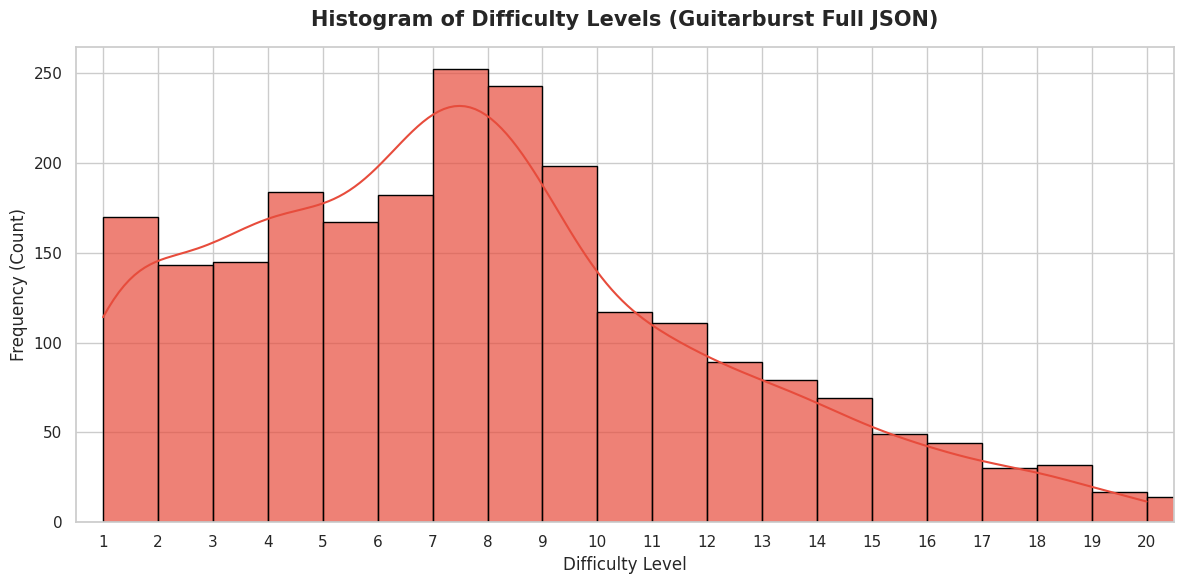

In [8]:
# Plot histogram of difficulty levels in the JSON dataset
plt.figure(figsize=(12, 6))

min_diff_json = int(df_json['Difficulty_Cleaned'].min()) if not pd.isna(df_json['Difficulty_Cleaned'].min()) else 1
max_diff_json = int(df_json['Difficulty_Cleaned'].max()) if not pd.isna(df_json['Difficulty_Cleaned'].max()) else 20
bins_json = range(min_diff_json, max_diff_json + 2)

sns.histplot(
    data=df_json,
    x='Difficulty_Cleaned',
    bins=bins_json,
    kde=True,
    color='#e74c3c',
    edgecolor='black',
    alpha=0.7
)

plt.title("Histogram of Difficulty Levels (Guitarburst Full JSON)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Difficulty Level", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.xticks(range(min_diff_json, max_diff_json + 1))
plt.xlim(min_diff_json - 0.5, max_diff_json + 0.5)
plt.tight_layout()
plt.show()